# Model Insights & Performance Analysis
Analyzes the trained Random Forest recommendation model.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Pre-requisites (if not installed):


meta_path = Path('../ml/models/training_meta.pkl')
if meta_path.exists():
    meta = joblib.load(meta_path)
    print("Metadata loaded successfully!")
else:
    print("Model metadata not found.")

Metadata loaded successfully!


## 1. Feature List (75 Features)
The exact features the model was trained on.

In [2]:
features = meta['feature_names']
print(f"Total Features: {len(features)}")
for i, f in enumerate(features):
    print(f"{i+1}. {f}")

Total Features: 75
1. grade_math
2. grade_physics
3. grade_chemistry
4. grade_biology
5. grade_english
6. grade_khmer
7. grade_history
8. grade_mean
9. grade_std
10. grade_max
11. stem_avg
12. lang_avg
13. stem_lang_ratio
14. math_phys_interaction
15. chem_bio_interaction
16. strength_logic
17. strength_communication
18. strength_creativity
19. strength_problem-solving
20. strength_analytical
21. strength_leadership
22. strength_teamwork
23. strength_technical
24. pref_coding
25. pref_analysis
26. pref_design
27. pref_networking
28. pref_research
29. pref_teaching
30. pref_helping
31. pref_building
32. sbert_sim_Architecture
33. sbert_sim_Business Administration
34. sbert_sim_Business Management
35. sbert_sim_Chemical Engineering
36. sbert_sim_Civil Engineering
37. sbert_sim_Cybersecurity
38. sbert_sim_Data Science
39. sbert_sim_Dentistry
40. sbert_sim_Education
41. sbert_sim_Electrical Engineering
42. sbert_sim_Finance
43. sbert_sim_Graphic Design
44. sbert_sim_International Relations

## 2. Model Performance Metrics
Display Train Accuracy, Test Accuracy, Weighted Precision, Weighted Recall, and the calculated F1 Score.

In [3]:
train_acc = meta.get("train_accuracy", 0.0)
acc = meta["test_accuracy"]
cv_acc_mean = meta["cv_accuracy_mean"]
p = meta["test_precision_weighted"]
r = meta["test_recall_weighted"]
f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

if train_acc > 0:
    print(f"Train Accuracy:         {train_acc:.4f} ({train_acc:.2%})")
    print(f"Test Accuracy:          {acc:.4f} ({acc:.2%})")
    print(f"Cross-Validation Acc:   {cv_acc_mean:.4f} ({cv_acc_mean:.2%})")
    print(f"Weighted Precision:     {p:.4f} ({p:.2%})")
    print(f"Weighted Recall:        {r:.4f} ({r:.2%})")
    print(f"Weighted F1 Score:      {f1:.4f} ({f1:.2%})")


Train Accuracy:         0.9869 (98.69%)
Test Accuracy:          0.9312 (93.12%)
Cross-Validation Acc:   0.9349 (93.49%)
Weighted Precision:     0.9322 (93.22%)
Weighted Recall:        0.9312 (93.12%)
Weighted F1 Score:      0.9317 (93.17%)


## 3. Confusion Matrix
Visualizing the model's predictions vs the actual true majors.

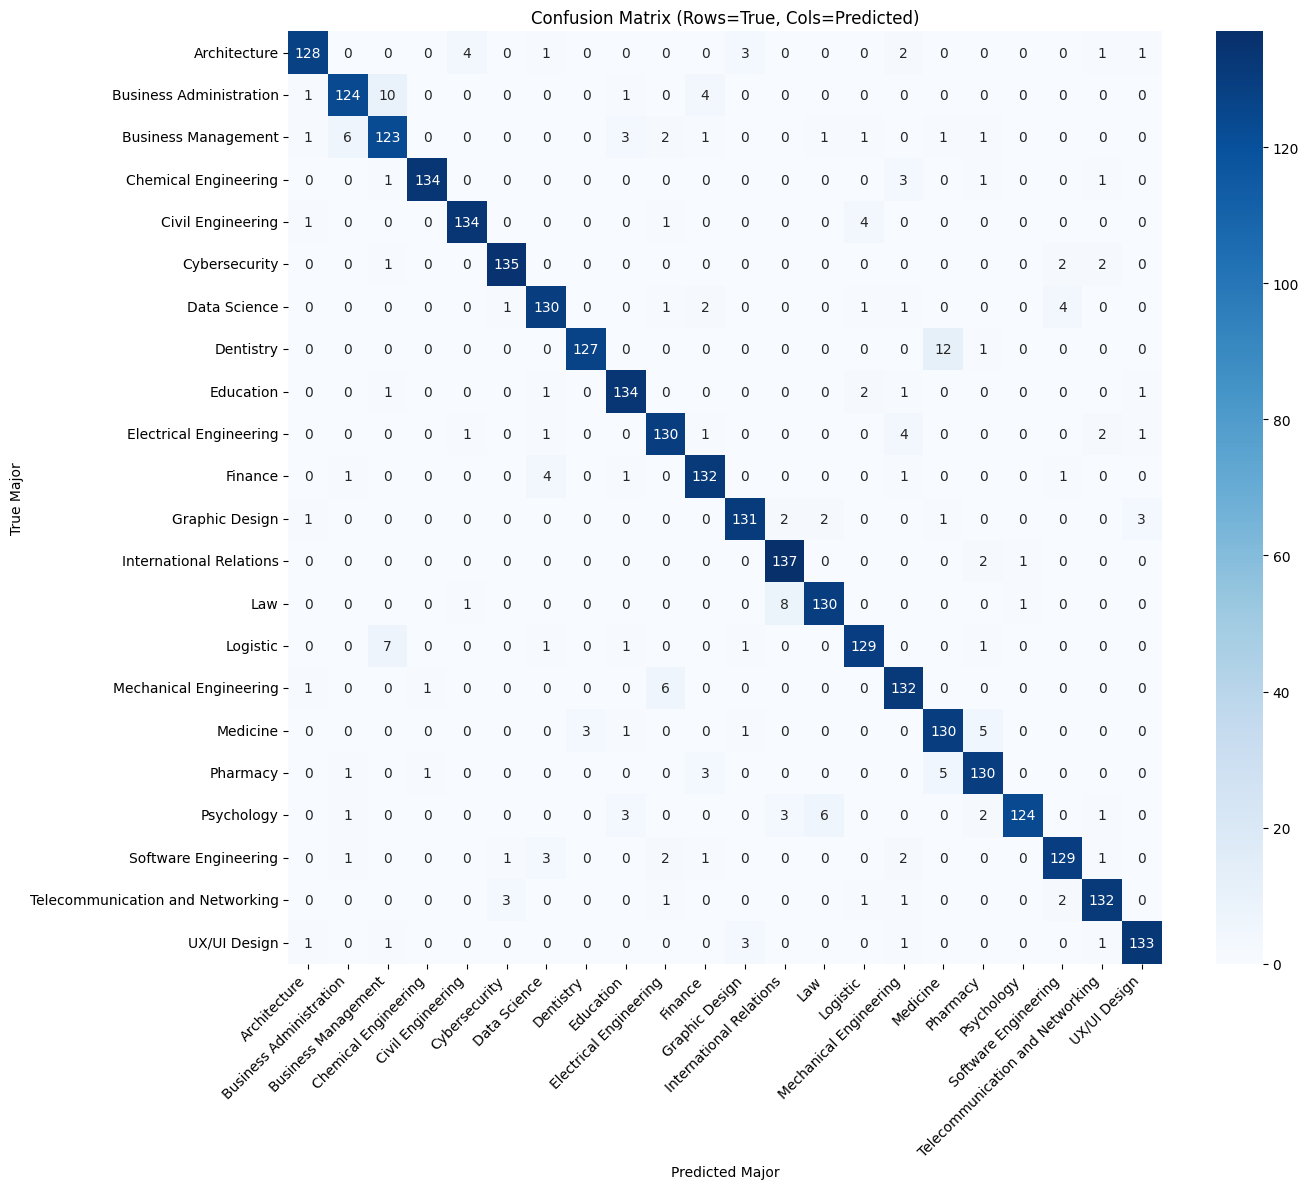

In [4]:
cm = meta['confusion_matrix']
classes = meta['classes']

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (Rows=True, Cols=Predicted)')
plt.ylabel('True Major')
plt.xlabel('Predicted Major')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()